In [10]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import math
import torch
import matplotlib.pyplot as plt

def find_repo_root(start_path=None):
    current = (start_path or Path.cwd()).resolve()
    while True:
        if (current / "data").is_dir() and (current / "data_setup").is_dir():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise RuntimeError("Could not locate necst-torch root directory")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from src.utils import build_dataloaders

train_loader, valid_loader, test_loader, input_dim = build_dataloaders(
    dataset_name="binarymnist",
    datadir=str(REPO_ROOT / "data"),
    batch_size=100,
)

# quick sanity check
batch = next(iter(train_loader))
print("Train batch shape:", batch.shape, "min/max:", batch.min().item(), batch.max().item())


Train batch shape: torch.Size([100, 1, 28, 28]) min/max: 0.0 1.0


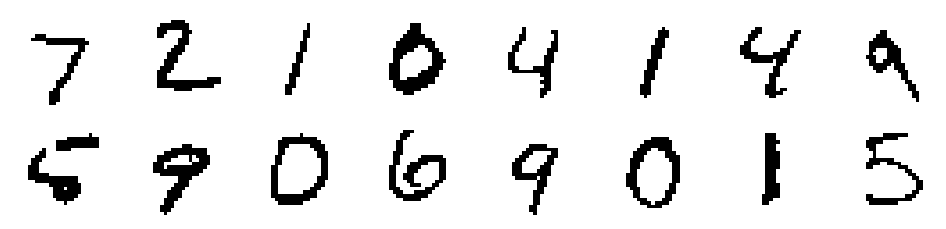

In [11]:
import matplotlib.pyplot as plt

def plot_binary_rows(data_loader, n_rows=2, n_cols=8):
    batch = next(iter(data_loader))
    imgs = batch[0] if isinstance(batch, (list, tuple)) else batch  # handles (imgs, labels) or imgs
    imgs = imgs[: n_rows * n_cols].detach().cpu()
    px = int(imgs.shape[-1] ** 0.5) if imgs.dim() == 2 else imgs.shape[-2]
    imgs = imgs.view(-1, px, px)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.2, n_rows * 1.2))
    for idx, img in enumerate(imgs):
        r, c = divmod(idx, n_cols)
        axes[r, c].imshow(img, cmap="gray_r", vmin=0, vmax=1)
        axes[r, c].axis("off")
    plt.tight_layout()
    plt.show()

plot_binary_rows(test_loader)


In [12]:
### noise 0.0 -- load model
import torch
from pathlib import Path
from src.necst import NecstTorch
from src.args import parse_architecture

ckpt_path = Path("../../models/mnist_vimco_0.0.pt")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(ckpt_path, map_location=device)
config = checkpoint.get("config", {})
state_dict = checkpoint.get("model_state", checkpoint)

# rebuild model with saved config (fallbacks if keys missing)
model = NecstTorch(
    input_dim=config.get("input_dim", 784),
    z_dim=config.get("latent_dim", 100),
    vimco_samples=config.get("vimco_samples", 5),
    noise=config.get("noise", 0.0),
    test_noise=config.get("test_noise", 0.0),
    encoder_layers=parse_architecture(config.get("enc_arch", "500")),
    decoder_layers=parse_architecture(config.get("dec_arch", "500,500")),
).to(device)

model.load_state_dict(state_dict)
model.eval()
print("Loaded model from", ckpt_path)

Loaded model from ../../models/mnist_vimco_0.0.pt


Test BCE per pixel: 0.064540 | per image: 50.621865


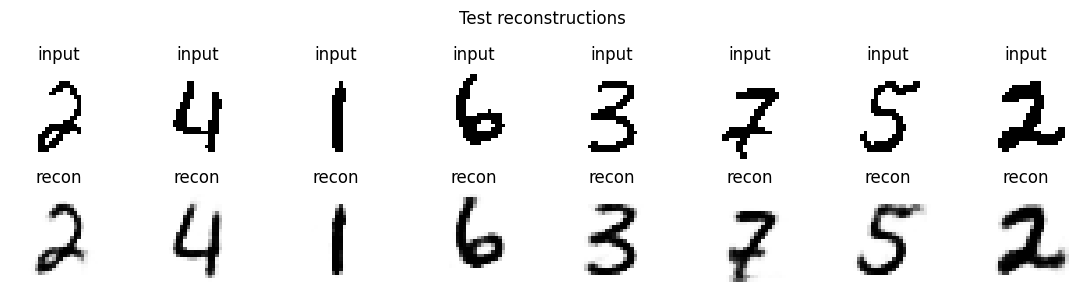

In [13]:
### noise 0.0

# load model

# test error (per sample/per image)
loss_per_pixel = model.evaluate_reconstruction(test_loader, per_element=True)
loss_per_image = model.evaluate_reconstruction(test_loader, per_element=False)
print(f"Test BCE per pixel: {loss_per_pixel:.6f} | per image: {loss_per_image:.6f}")


# image reconstructions
fig = model.plot_reconstructions(test_loader, n_samples=8, title="Test reconstructions")
plt.show()

two images selected:


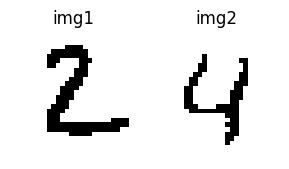

printing interpolation:


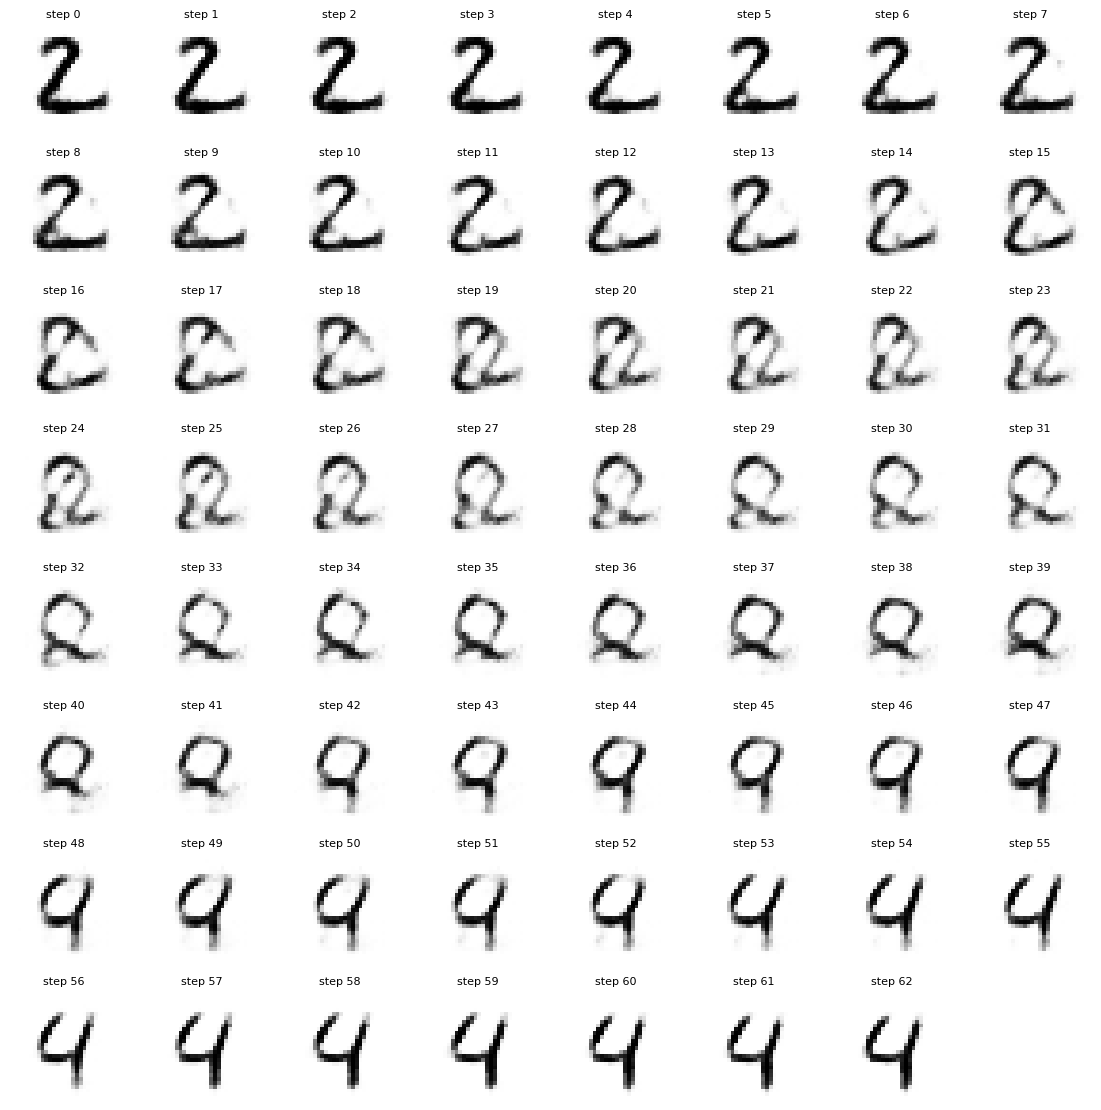

In [39]:
import math, random, numpy as np, torch, matplotlib.pyplot as plt

# 1) deterministic loaders + sampling
SEED = 12114
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 2) grab the first batch from the non-shuffled test loader
batch = next(iter(test_loader))
imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
img1 = imgs[1].to(device)
img2 = imgs[4].to(device)

print("two images selected:")
fig, axes = plt.subplots(1, 2, figsize=(3, 2))
axes[0].imshow(img1.view(28, 28).cpu(), cmap="gray_r", vmin=0, vmax=1)
axes[0].axis("off"); axes[0].set_title("img1")
axes[1].imshow(img2.view(28, 28).cpu(), cmap="gray_r", vmin=0, vmax=1)
axes[1].axis("off"); axes[1].set_title("img2")
plt.tight_layout(); plt.show()

# 3) run interpolation as before using img1/img2
print("printing interpolation:")
with torch.no_grad():
    y1, _, _ = model.forward_test(img1.unsqueeze(0))
    y2, _, _ = model.forward_test(img2.unsqueeze(0))

y1_vec, y2_vec = y1.squeeze(0).clone(), y2.squeeze(0).clone()
recons = []

def decode_bits(z_bits):
    logits = model.decoder(z_bits.unsqueeze(0))
    return torch.sigmoid(logits).view(28, 28).cpu()

with torch.no_grad():
    recons.append(decode_bits(y1_vec))
    for i in range(y1_vec.numel()):
        if y1_vec[i].item() != y2_vec[i].item():
            y1_vec[i] = y2_vec[i]
            recons.append(decode_bits(y1_vec))

cols = 8
rows = math.ceil(len(recons) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.4, rows * 1.4))
axes = axes.flatten()
for idx, img in enumerate(recons):
    axes[idx].imshow(img, cmap="gray_r", vmin=0, vmax=1)
    axes[idx].axis("off")
    axes[idx].set_title(f"step {idx}", fontsize=8)
for ax in axes[len(recons):]:
    ax.axis("off")
plt.tight_layout(); plt.show()
